# Sprint 4 — Feature Selection : Mutual Information (DS1)

**Auteur** : TAYAR Ali  
**Objectif** : Sélectionner les features les plus informatives avec MI et mesurer l'impact sur le LSTM.

---


## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import sys
import time

sys.path.append('../src')

from sklearn.metrics import (f1_score, precision_score, 
                             recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from models.lstm_model import build_lstm_model
from feature_selection.mutual_information import (
    compute_mi_scores, select_top_k_features, rebuild_sequences
)

PROCESSED_PATH = '../data/processed/'
SCORES_PATH    = '../results/scores/'
FIGURES_PATH   = '../results/figures/'
os.makedirs(SCORES_PATH, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Chargement des données

In [2]:
# Séquences paddées et labels
X_train_pad = np.load(f'{PROCESSED_PATH}X_train_pad.npy')
X_val_pad   = np.load(f'{PROCESSED_PATH}X_val_pad.npy')
X_test_pad  = np.load(f'{PROCESSED_PATH}X_test_pad.npy')
y_train     = np.load(f'{PROCESSED_PATH}y_train.npy')
y_val       = np.load(f'{PROCESSED_PATH}y_val.npy')
y_test      = np.load(f'{PROCESSED_PATH}y_test.npy')

# Textes splittés
X_train_text = pd.read_csv(f'{PROCESSED_PATH}X_train_text.csv')['text']
X_val_text   = pd.read_csv(f'{PROCESSED_PATH}X_val_text.csv')['text']
X_test_text  = pd.read_csv(f'{PROCESSED_PATH}X_test_text.csv')['text']

# Objets preprocessing
with open(f'{PROCESSED_PATH}tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open(f'{PROCESSED_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Paramètres
with open(f'{PROCESSED_PATH}ds1_params.json', 'r') as f:
    params = json.load(f)

MAXLEN     = params['maxlen']
VOCAB_SIZE = params['vocab_size']
N_CLASSES  = params['n_classes']

print(f'Données chargées')
print(f'X_train_text : {len(X_train_text):,}')
print(f'y_train      : {len(y_train):,}')
print(f'MAXLEN       : {MAXLEN}')
print(f'VOCAB_SIZE   : {VOCAB_SIZE}')
print(f'N_CLASSES    : {N_CLASSES}')

Données chargées
X_train_text : 10,106
y_train      : 10,106
MAXLEN       : 179
VOCAB_SIZE   : 10000
N_CLASSES    : 5


## 2. Calcul des scores Mutual Information

In [3]:
import warnings
warnings.filterwarnings('ignore')

X_train_tfidf = tfidf.transform(X_train_text)
feature_names = tfidf.get_feature_names_out()

print('Calcul des scores MI en cours...')
mi_scores = compute_mi_scores(X_train_tfidf, y_train, feature_names)
print(f'MI calculé sur {len(mi_scores):,} features')

print('\nTop 20 features les plus informatives :')
for i, (word, score) in enumerate(list(mi_scores.items())[:20]):
    print(f'  {i+1:2}. {word:<25} {score:.4f}')

Calcul des scores MI en cours...
MI calculé sur 10,000 features

Top 20 features les plus informatives :
   1. patient                   0.8501
   2. study                     0.4611
   3. result                    0.3485
   4. disease                   0.3444
   5. case                      0.3353
   6. year                      0.3282
   7. treatment                 0.3045
   8. group                     0.2898
   9. clinical                  0.2649
  10. associated                0.2500
  11. effect                    0.2452
  12. significant               0.2378
  13. significantly             0.2315
  14. compared                  0.2269
  15. cell                      0.2234
  16. mean                      0.2198
  17. rate                      0.2140
  18. control                   0.2051
  19. found                     0.2022
  20. age                       0.2000


## 3. Visualisation des Top 50 Features par Mutual Information

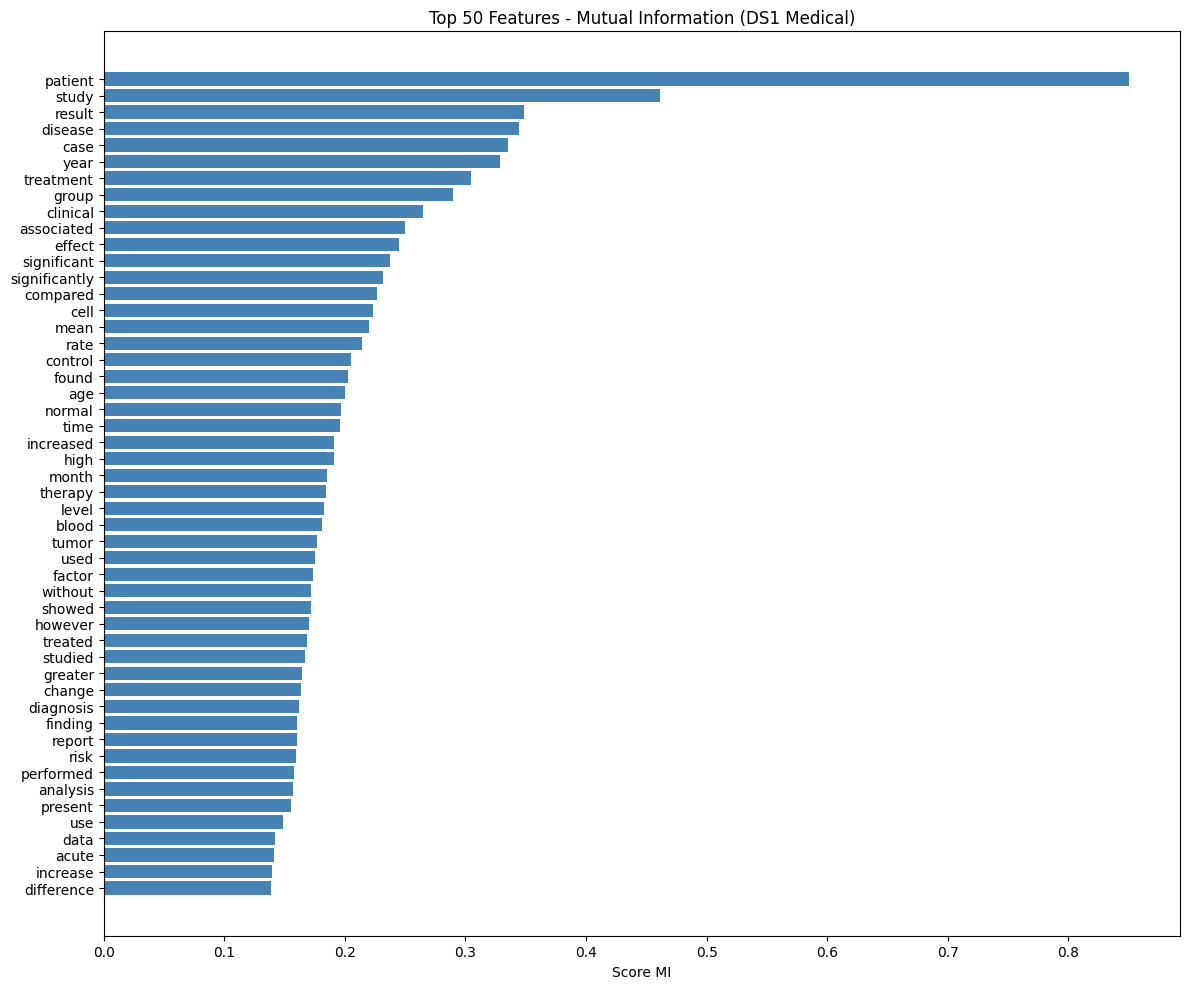

Figure sauvegardée : results/figures/mi_top50_ds1.png


In [4]:
# Convertir mi_scores en DataFrame si c'est un dict
if isinstance(mi_scores, dict):
    mi_df = pd.DataFrame(list(mi_scores.items()), columns=['feature', 'mi_score'])
    mi_df = mi_df.sort_values('mi_score', ascending=False).reset_index(drop=True)
else:
    mi_df = mi_scores

# Top 50 features
top50 = mi_df.head(50)

plt.figure(figsize=(12, 10))
plt.barh(range(len(top50)), top50['mi_score'].values[::-1], color='steelblue')
plt.yticks(range(len(top50)), top50['feature'].values[::-1])
plt.xlabel('Score MI')
plt.title('Top 50 Features - Mutual Information (DS1 Medical)')
plt.tight_layout()
plt.savefig('../results/figures/mi_top50_ds1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : results/figures/mi_top50_ds1.png")

## 4. Test des différentes valeurs de k (k=500, 1000, 2000)

In [5]:
k_values = [500, 1000, 2000]
datasets = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Sélection des top {k} features MI")
    print(f"{'='*50}")
    
    # Sélectionner les top k features (mi_df doit être un dict)
    mi_dict = dict(zip(mi_df['feature'], mi_df['mi_score']))
    selected_vocab = select_top_k_features(mi_dict, k=k)
    
    # Reconstruire les séquences (les 3 splits en même temps)
    X_train_k, X_val_k, X_test_k, tokenizer_k = rebuild_sequences(
        X_train_text, X_val_text, X_test_text,
        top_features=selected_vocab,
        maxlen=MAXLEN
    )
    
    datasets[k] = {
        'X_train':   X_train_k,
        'X_val':     X_val_k,
        'X_test':    X_test_k,
        'tokenizer': tokenizer_k,
        'vocab':     selected_vocab
    }
    
    print(f"  → Train shape : {X_train_k.shape}")
    print(f"  → Val shape   : {X_val_k.shape}")
    print(f"  → Test shape  : {X_test_k.shape}")

print("\nDonnées prêtes pour les 3 valeurs de k ")


Sélection des top 500 features MI
  → Train shape : (10106, 179)
  → Val shape   : (2166, 179)
  → Test shape  : (2166, 179)

Sélection des top 1000 features MI
  → Train shape : (10106, 179)
  → Val shape   : (2166, 179)
  → Test shape  : (2166, 179)

Sélection des top 2000 features MI
  → Train shape : (10106, 179)
  → Val shape   : (2166, 179)
  → Test shape  : (2166, 179)

Données prêtes pour les 3 valeurs de k 


## 5. Entraînement LSTM pour k=500, 1000, 2000

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from models.lstm_model import build_lstm_model  # ← import ajouté

results_mi = {}

for k in [500, 1000, 2000]:
    print(f"\n{'='*55}")
    print(f"LSTM avec MI k={k}")
    print(f"{'='*55}")
    
    X_train_k = datasets[k]['X_train']
    X_val_k   = datasets[k]['X_val']
    X_test_k  = datasets[k]['X_test']
    
    model = build_lstm_model(
        vocab_size=k + 1,
        maxlen=MAXLEN,
        n_classes=N_CLASSES
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f'../results/best_model_mi_k{k}.keras', save_best_only=True)
    ]
    
    history = model.fit(
        X_train_k, y_train,
        validation_data=(X_val_k, y_val),
        epochs=20, batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    
    y_pred = np.argmax(model.predict(X_test_k), axis=1)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    
    results_mi[k] = {'accuracy': acc, 'f1_macro': f1}
    print(f"\nk={k} → Accuracy: {acc:.4f} | F1 macro: {f1:.4f}")

print("\nEntraînement terminé pour tous les k")


LSTM avec MI k=500
Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 150s 431ms/step - accuracy: 0.4645 - loss: 1.3014 - val_accuracy: 0.5102 - val_loss: 1.3831
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 117s 370ms/step - accuracy: 0.5418 - loss: 1.1256 - val_accuracy: 0.5725 - val_loss: 1.0905
Epoch 3/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 120s 381ms/step - accuracy: 0.5667 - loss: 1.0715 - val_accuracy: 0.5683 - val_loss: 1.0627
Epoch 4/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 128s 336ms/step - accuracy: 0.5813 - loss: 1.0231 - val_accuracy: 0.5623 - val_loss: 1.0906
Epoch 5/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 147s 351ms/step - accuracy: 0.5801 - loss: 0.9992 - val_accuracy: 0.5619 - val_loss: 1.0789
Epoch 6/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 116s 368ms/step - accuracy: 0.5881 - loss: 0.9814 - val_accuracy: 0.5462 - val_loss: 1.0812
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step

k=500 → Accuracy: 0.5716 | F1 macro: 0.5217

LSTM avec MI k=1000
Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 128s 359ms/step - accuracy: 0.4747 - loss:

## 7. Comparaison des résultats MI vs Baseline

In [7]:
import pandas as pd

# Résultats
comparison = pd.DataFrame({
    'methode':    ['baseline', 'MI_k500', 'MI_k1000', 'MI_k2000'],
    'dataset':    ['DS1_medical'] * 4,
    'accuracy':   [0.6122, round(results_mi[500]['accuracy'], 4),
                          round(results_mi[1000]['accuracy'], 4),
                          round(results_mi[2000]['accuracy'], 4)],
    'f1_macro':   [0.5989, round(results_mi[500]['f1_macro'], 4),
                          round(results_mi[1000]['f1_macro'], 4),
                          round(results_mi[2000]['f1_macro'], 4)],
    'n_features': [10000, 500, 1000, 2000]
})

print(comparison.to_string(index=False))

# Sauvegarder
comparison.to_csv('../results/scores/mi_results_ds1.csv', index=False)
print("\nRésultats sauvegardés ")

 methode     dataset  accuracy  f1_macro  n_features
baseline DS1_medical    0.6122    0.5989       10000
 MI_k500 DS1_medical    0.5716    0.5217         500
MI_k1000 DS1_medical    0.6034    0.5900        1000
MI_k2000 DS1_medical    0.6122    0.5979        2000

Résultats sauvegardés 
